In [1]:
import matplotlib.pyplot as plt
import numpy as np
from src.discrete_fourier_transform import dft2d
from src.utils import fourier_spectrum, create_white_square, rgb2gray

(512, 512)


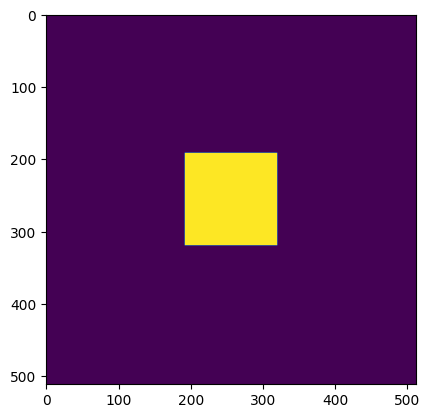

np.uint8(255)

In [2]:
# Example: 10x10 image with a 4x4 white square in the center
n = 512
square_size = 128
image = create_white_square(n, square_size)

# image = plt.imread("Lab1-Inverting_Image/crying-cat-meme.jpg")
print(image.shape) # show the dimensions of the image
plt.imshow(image)
plt.show()

image[200,200]

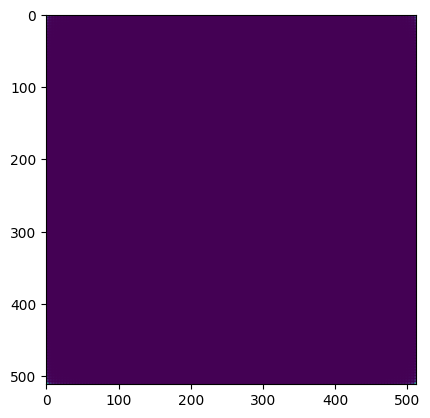

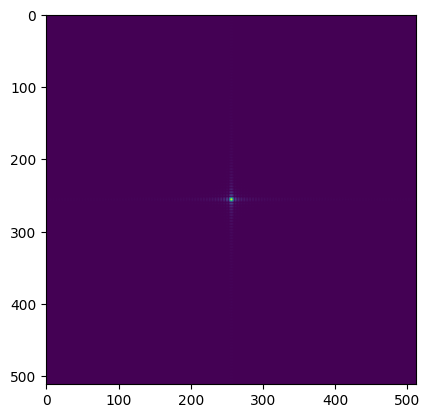

In [3]:
f = np.fft.fft2(image)
f_centered = np.fft.fftshift(f)
real_f = f.real
imag_f = f.imag

np_fs_image = fourier_spectrum(real_f, imag_f)

f_centered = np.fft.fftshift(f)
real_f_centered = f_centered.real
imag_f_centered = f_centered.imag

np_centered_fs_image = fourier_spectrum(real_f_centered, imag_f_centered)

plt.imshow(np_fs_image)
plt.show()

plt.imshow(np_centered_fs_image)
plt.show()

In [4]:
from src.fast_fourier_transform import fft2d

(512, 512)


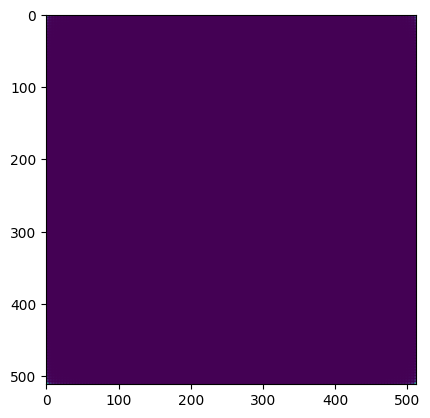

In [5]:
temp_fft, info = fft2d(image)

# temp_fft = temp_fft.transpose(2,0,1)
print(temp_fft.shape)
fft_real = temp_fft.real
fft_imaginary  = temp_fft.imag

dft_fs_image = fourier_spectrum(fft_real, fft_imaginary)

plt.imshow(dft_fs_image)
plt.show()

In [6]:
print(f[2,10])
print(temp_fft[2,10])

(337952.3541080366+24928.863282452825j)
(337952.3541080365+24928.863282452956j)


In [7]:
fft_real.shape

(512, 512)

In [8]:
temp_fft

array([[ 4177920.        +0.00000000e+00j,
        -3761402.33784939-2.30799653e+04j,
         2659612.96034167+3.26400000e+04j, ...,
        -1253674.89444019+2.30799653e+04j,
         2659612.96034167-3.26400000e+04j,
        -3761402.33784939+2.30799653e+04j],
       [-3761402.33784939-2.30799653e+04j,
         3386281.89682399+4.15580172e+04j,
        -2394282.58002429-4.40783804e+04j, ...,
         1128817.29751896-1.38533678e+04j,
        -2394643.20448269+1.46935311e+04j,
         3386536.89682399+4.13203758e-09j],
       [ 2659612.96034167+3.26400000e+04j,
        -2394282.58002429-4.40783804e+04j,
         1692822.20081221+4.15564525e+04j, ...,
         -798254.47289003+4.89808957e+03j,
         1693332.20081221+1.67670154e-09j,
        -2394643.20448269-1.46935311e+04j],
       ...,
       [-1253674.89444019+2.30799653e+04j,
         1128817.29751896-1.38533678e+04j,
         -798254.47289003+4.89808957e+03j, ...,
          376064.65804745-1.38512816e+04j,
         -797893.84

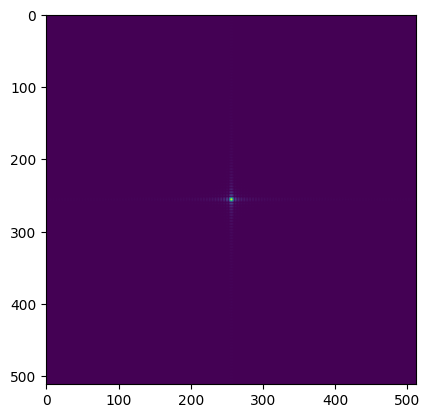

In [9]:
from src.utils import center_fourier

temp_fft_centered = center_fourier(temp_fft)

cent_fft_real = temp_fft_centered.real
cent_fft_imaginary = temp_fft_centered.imag

dft_fs_image = fourier_spectrum(cent_fft_real, cent_fft_imaginary)

plt.imshow(dft_fs_image)

In [10]:
image_reconstruct, info = fft2d(temp_fft,inverse=True)

# plt.imshow(image_reconstruct)


(254.99999999999983+1.1893372545944431e-13j)


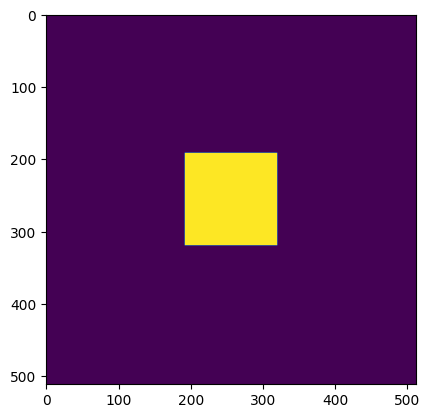

In [13]:
print(image_reconstruct[200,200])

bruh = image_reconstruct.real

plt.imshow(bruh)
plt.show()

## Visualiztion

In [33]:
inverse = False
sign = -1 if inverse else 1
sign

1

In [ ]:
info['ee'][0][1].relative_cord

TypeError: 'NoneType' object is not subscriptable

In [ ]:
def see_partition(partition):
    if partition.dependants is None:
        return
    
    for dependant in partition.dependants:
        see_partition(dependant)
        if dependant.dependants is None:
            print("f" + str(partition.image_cord) + " | F" + partition.partition_string + str(partition.relative_cord))
        else:
            print("F" + partition.partition_string + str(partition.relative_cord))


In [ ]:
def see_partition(partition):
    if partition.dependants is None:
        print("F" + partition.partition_string + str(partition.relative_cord) + "\tf" + str(partition.image_cord))
        return
    
    for dependant in partition.dependants:
        see_partition(dependant)
    print("F" + partition.partition_string + str(partition.relative_cord) +  f"\tW top={partition.weight_params_top} bottom={partition.weight_params_bottom}")

In [ ]:
partition = info[''][1][0]


see_partition(partition)

Feeeeee(1, 0)	f[[[0, 0], [0, 8]], [[8, 0], [8, 8]]]
Feeeeeo(1, 0)	f[[[4, 0], [4, 8]], [[12, 0], [12, 8]]]
Feeeeoe(1, 0)	f[[[0, 4], [0, 12]], [[8, 4], [8, 12]]]
Feeeeoo(1, 0)	f[[[4, 4], [4, 12]], [[12, 4], [12, 12]]]
Feeee(1, 0)	W top=[0, 0, 1, 1] bottom=4.0
Feeeoee(1, 0)	f[[[2, 0], [2, 8]], [[10, 0], [10, 8]]]
Feeeoeo(1, 0)	f[[[6, 0], [6, 8]], [[14, 0], [14, 8]]]
Feeeooe(1, 0)	f[[[2, 4], [2, 12]], [[10, 4], [10, 12]]]
Feeeooo(1, 0)	f[[[6, 4], [6, 12]], [[14, 4], [14, 12]]]
Feeeo(1, 0)	W top=[0, 0, 1, 1] bottom=4.0
Feeoeee(1, 0)	f[[[0, 2], [0, 10]], [[8, 2], [8, 10]]]
Feeoeeo(1, 0)	f[[[4, 2], [4, 10]], [[12, 2], [12, 10]]]
Feeoeoe(1, 0)	f[[[0, 6], [0, 14]], [[8, 6], [8, 14]]]
Feeoeoo(1, 0)	f[[[4, 6], [4, 14]], [[12, 6], [12, 14]]]
Feeoe(1, 0)	W top=[0, 0, 1, 1] bottom=4.0
Feeooee(1, 0)	f[[[2, 2], [2, 10]], [[10, 2], [10, 10]]]
Feeooeo(1, 0)	f[[[6, 2], [6, 10]], [[14, 2], [14, 10]]]
Feeoooe(1, 0)	f[[[2, 6], [2, 14]], [[10, 6], [10, 14]]]
Feeoooo(1, 0)	f[[[6, 6], [6, 14]], [[14, 6], [14, 

In [ ]:
print(info.partitions['eeee'])

[[<src.fast_fourier_transform.fft_partition object at 0x000001B7E82C3640>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6236C80>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E82C3A90>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6236AA0>], [<src.fast_fourier_transform.fft_partition object at 0x000001B7E6234700>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E62373D0>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6237FA0>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6234730>], [<src.fast_fourier_transform.fft_partition object at 0x000001B7E82C3670>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6236980>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E5FE77C0>, <src.fast_fourier_transform.fft_partition object at 0x000001B7E6235FC0>], [<src.fast_fourier_transform.fft_partition object at 0x000001B7E6236110>, <src.fast_fourier_transform.fft_partition o

## Sanity Check

In [ ]:
# are_equal = np.allclose(dft_fs_image, np_fs_image, rtol=1e-6, atol=1e-9)

# print("Are the arrays equal to the given precision?", are_equal)
are_equal = np.allclose(fft_imaginary, imag_f, rtol=1e-6, atol=1e-9)

print("Are the arrays equal to the given precision?", are_equal)
are_equal = np.allclose(fft_real, real_f, rtol=1e-6, atol=1e-9)

print("Are the arrays equal to the given precision?", are_equal)

Are the arrays equal to the given precision? True
Are the arrays equal to the given precision? True
